# Normal Distribution

Normal distribution is a continuous probability distribution that is
symmetric around its mean.

It is also called the Gaussian distribution and has a bell-shaped curve.

A normal distribution is mainly described by:

- Mean (μ): determines the center of the distribution
- Standard deviation (σ): determines the spread of the distribution

## Properties of Normal Distribution

The important properties of a normal distribution are:

- It is symmetric around the mean.
- Mean, median, and mode are approximately equal.
- The total area under the curve is equal to 1.
- About 68% of observations lie within 1 standard deviation of the mean.
- About 95% lie within 2 standard deviations.
- About 99.7% lie within 3 standard deviations.

This is known as the empirical rule or 68–95–99.7 rule.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Mean and Standard Deviation

The mean represents the center of a normal distribution.

The standard deviation represents how spread out the data is around the mean.

A smaller standard deviation produces a narrower curve, while a larger
standard deviation produces a wider curve.

In [2]:
mean = 50
std = 10

print("Mean:", mean)
print("Standard deviation:", std)

Mean: 50
Standard deviation: 10


In [3]:
data = np.random.normal(mean, std, 1000)

print("Mean of generated data:", np.mean(data))
print("Standard deviation of generated data:", np.std(data))

Mean of generated data: 49.40916852075757
Standard deviation of generated data: 9.989161675411012


## Visualizing Normal Distribution

A normal distribution can be visualized using a histogram and a smooth
density curve.

The bell-shaped curve shows how the observations are distributed around
the mean.

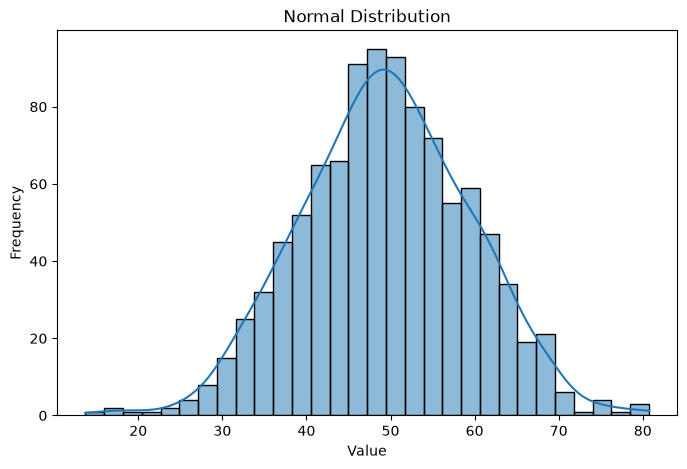

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(data, bins=30, kde=True)

plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

### Observation

The histogram shows a bell-shaped distribution centered approximately
around the mean.

Most observations are concentrated near the center, while fewer
observations occur toward the extremes.

## 68–95–99.7 Rule

The empirical rule describes the percentage of observations that fall
within a certain number of standard deviations from the mean.

- Approximately 68% of observations lie within 1 standard deviation.
- Approximately 95% lie within 2 standard deviations.
- Approximately 99.7% lie within 3 standard deviations.

In [5]:
within_1_std = np.sum((data >= mean - std) & (data <= mean + std))
within_2_std = np.sum((data >= mean - 2*std) & (data <= mean + 2*std))
within_3_std = np.sum((data >= mean - 3*std) & (data <= mean + 3*std))

print("Within 1 standard deviation:", within_1_std / len(data) * 100, "%")
print("Within 2 standard deviations:", within_2_std / len(data) * 100, "%")
print("Within 3 standard deviations:", within_3_std / len(data) * 100, "%")

Within 1 standard deviation: 67.0 %
Within 2 standard deviations: 96.7 %
Within 3 standard deviations: 99.4 %


### Observation

The generated data approximately follows the empirical rule.

Around 68% of observations fall within 1 standard deviation,
95% within 2 standard deviations, and 99.7% within 3 standard deviations.

Small differences from these values are expected because the dataset is
randomly generated.

## Standard Normal Distribution and Z-Score

A standard normal distribution has:

- Mean = 0
- Standard deviation = 1

A z-score tells us how many standard deviations an observation is away
from the mean.

The formula is:

z = (x - μ) / σ

where:

x = observation
μ = mean
σ = standard deviation

In [6]:
x = 70

z_score = (x - mean) / std

print("Value:", x)
print("Z-score:", z_score)

Value: 70
Z-score: 2.0


In [7]:
z_scores = (data - np.mean(data)) / np.std(data)

print(z_scores[:10])
print("Mean of z-scores:", np.mean(z_scores))
print("Standard deviation of z-scores:", np.std(z_scores))

[ 0.03200686  1.04339176  0.12612843 -0.27349364  0.5786347  -0.25037656
 -1.0207157  -0.37484858 -0.50726334 -1.09575048]
Mean of z-scores: -5.417888360170764e-17
Standard deviation of z-scores: 0.9999999999999999


## Normal Distribution in the Wine Quality Dataset

The theoretical properties of a normal distribution can now be examined
using a real-world dataset.

We will analyze the `pH` variable because its histogram from the EDA
showed a relatively symmetric, bell-shaped distribution.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("../data/WineQT.csv")

ph = df["pH"]

print("Mean:", ph.mean())
print("Median:", ph.median())
print("Standard deviation:", ph.std())

Mean: 3.3110148731408575
Median: 3.31
Standard deviation: 0.15666405977275194


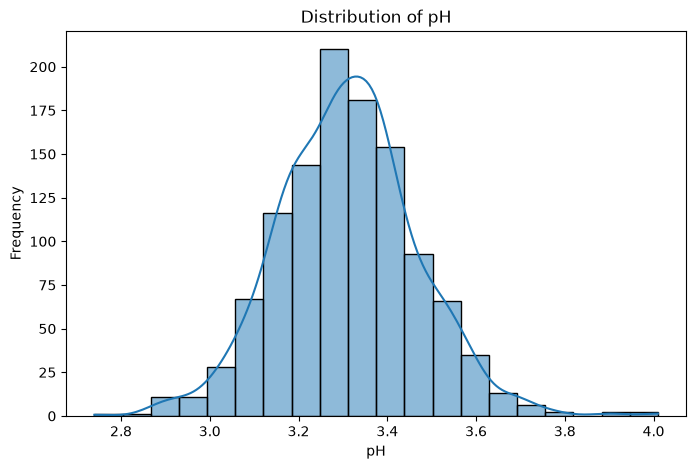

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(ph, bins=20, kde=True)

plt.title("Distribution of pH")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()

## 68–95–99.7 Rule on Wine pH

We can check how many pH observations fall within 1, 2, and 3 standard
deviations from the mean.

For a normally distributed variable, approximately:

- 68% should lie within 1 standard deviation.
- 95% should lie within 2 standard deviations.
- 99.7% should lie within 3 standard deviations.

In [12]:
mean_ph = ph.mean()
std_ph = ph.std()

within_1 = np.sum((ph >= mean_ph - std_ph) & (ph <= mean_ph + std_ph))
within_2 = np.sum((ph >= mean_ph - 2*std_ph) & (ph <= mean_ph + 2*std_ph))
within_3 = np.sum((ph >= mean_ph - 3*std_ph) & (ph <= mean_ph + 3*std_ph))

total = len(ph)

print("Within 1 standard deviation:", within_1 / total * 100, "%")
print("Within 2 standard deviations:", within_2 / total * 100, "%")
print("Within 3 standard deviations:", within_3 / total * 100, "%")

Within 1 standard deviation: 70.34120734908137 %
Within 2 standard deviations: 95.71303587051618 %
Within 3 standard deviations: 99.56255468066492 %


### Observation

The percentages obtained from the WineQT pH data can be compared with
the theoretical 68–95–99.7 rule.

The values may not exactly match the theoretical percentages because the
WineQT pH data is a real dataset and is only approximately normally
distributed.

## Comparing Different Standard Deviations

The spread of a normal distribution depends on its standard deviation.

A smaller standard deviation produces a narrower distribution, while a
larger standard deviation produces a wider distribution.

The mean remains the same in both cases.

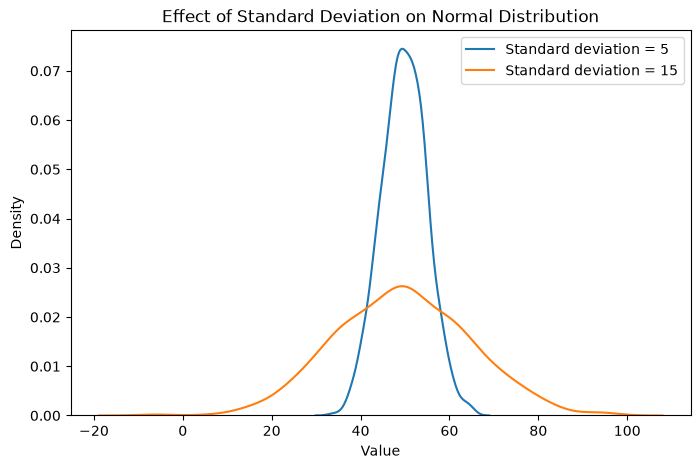

In [13]:
mean = 50

data_std_5 = np.random.normal(mean, 5, 1000)
data_std_15 = np.random.normal(mean, 15, 1000)

plt.figure(figsize=(8, 5))

sns.kdeplot(data_std_5, label="Standard deviation = 5")
sns.kdeplot(data_std_15, label="Standard deviation = 15")

plt.title("Effect of Standard Deviation on Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

### Observation

Both distributions have approximately the same mean, but their spread is
different.

The distribution with standard deviation 5 is narrower, while the
distribution with standard deviation 15 is wider.

Therefore, standard deviation controls the spread of a normal
distribution.

## Conclusion

Normal distribution is an important concept in data analysis and statistics.

In this notebook, we learned:

- The meaning and properties of a normal distribution.
- The role of mean and standard deviation.
- The 68–95–99.7 empirical rule.
- Z-score and standardization.
- How to visualize a normal distribution.
- How to examine normality using the WineQT `pH` variable.
- How standard deviation affects the spread of a distribution.

The WineQT pH variable appears approximately symmetric and bell-shaped,
but real-world data does not need to follow a perfect normal distribution.

### Practical Takeaway

Normal distribution helps us understand the center, spread, and
probability of observations in a dataset.

It is widely used in exploratory data analysis, statistical analysis,
standardization, outlier detection, and machine learning.